<a href="https://colab.research.google.com/github/venezianof/booksum/blob/main/INVIDIANEMOTRON35MIO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -U transformers

## Local Inference on GPU
Model page: https://huggingface.co/nvidia/NVIDIA-Nemotron-3.5-Lightning-30B-A3B-NVFP4

⚠️ If the generated code snippets do not work, please open an issue on either the [model repo](https://huggingface.co/nvidia/NVIDIA-Nemotron-3.5-Lightning-30B-A3B-NVFP4)
			and/or on [huggingface.js](https://github.com/huggingface/huggingface.js/blob/main/packages/tasks/src/model-libraries-snippets.ts) 🙏

In [ ]:
# Use a pipeline as a high-level helper
from transformers import pipeline

pipe = pipeline("text-generation", model="nvidia/NVIDIA-Nemotron-3.5-Lightning-30B-A3B-NVFP4")
messages = [
    {"role": "user", "content": "Who are you?"},
]
pipe(messages)

In [ ]:
# Load model directly
from transformers import AutoTokenizer, AutoModelForCausalLM

tokenizer = AutoTokenizer.from_pretrained("nvidia/NVIDIA-Nemotron-3.5-Lightning-30B-A3B-NVFP4")
model = AutoModelForCausalLM.from_pretrained("nvidia/NVIDIA-Nemotron-3.5-Lightning-30B-A3B-NVFP4", device_map="auto")
messages = [
    {"role": "user", "content": "Who are you?"},
]
inputs = tokenizer.apply_chat_template(
	messages,
	add_generation_prompt=True,
	tokenize=True,
	return_dict=True,
	return_tensors="pt",
).to(model.device)

outputs = model.generate(**inputs, max_new_tokens=40)
print(tokenizer.decode(outputs[0][inputs["input_ids"].shape[-1]:]))

### Medical Research & Medline Bibliography
We will use the `Biopython` library to interact with the Entrez databases (PubMed/Medline) for medical therapy and image-related research.

In [ ]:
!pip install biopython

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 55.4 MB/s eta 0:00:00


In [ ]:
from Bio import Entrez
import pandas as pd

def search_medline(query, max_results=20):
    Entrez.email = 'your_email@example.com'
    handle = Entrez.esearch(db='pubmed', sort='relevance', retmax=max_results, retmode='xml', term=query)
    results = Entrez.read(handle)
    return results['IdList']

def fetch_details(id_list):
    ids = ','.join(id_list)
    handle = Entrez.efetch(db='pubmed', retmode='xml', id=ids)
    results = Entrez.read(handle)
    return results

# Query clinica
clinical_query = '"cytoreductive nephrectomy" AND "systemic therapy" AND "poor prognosis" AND "renal cell carcinoma"'
studies_ids = search_medline(clinical_query)

if studies_ids:
    papers = fetch_details(studies_ids)
    output = []
    for paper in papers['PubmedArticle']:
        article = paper['MedlineCitation']['Article']
        title = article['ArticleTitle']
        # Estrazione dell'anno di pubblicazione
        pub_date = article['Journal']['JournalIssue']['PubDate']
        year = pub_date.get('Year', 'N/A')

        abstract_text = " ".join(article['Abstract']['AbstractText']) if 'Abstract' in article else "No abstract"
        output.append({'Title': title, 'Year': year, 'Abstract': abstract_text})

    df_results = pd.DataFrame(output)
    display(df_results.head())
else:
    print('Nessun risultato trovato.')

,Title,Year,Abstract
0,Cytoreductive nephrectomy in metastatic renal ...,2006,Metastatic renal cell carcinoma is associated ...
1,Optimal treatment of poor-risk renal cell carc...,2016,Poor-risk metastatic renal cell carcinoma (RCC...
2,Surgical management in metastatic renal cell c...,2022,The management of metastatic renal cell carcin...
3,How Targeted Therapy Influence Renal Surgery f...,2020,Between the end of 2005 and the beginning of 2...
4,Survival benefits of Cytoreductive Nephrectomy...,2025,Metastatic renal cell carcinoma (mRCC) is asso...


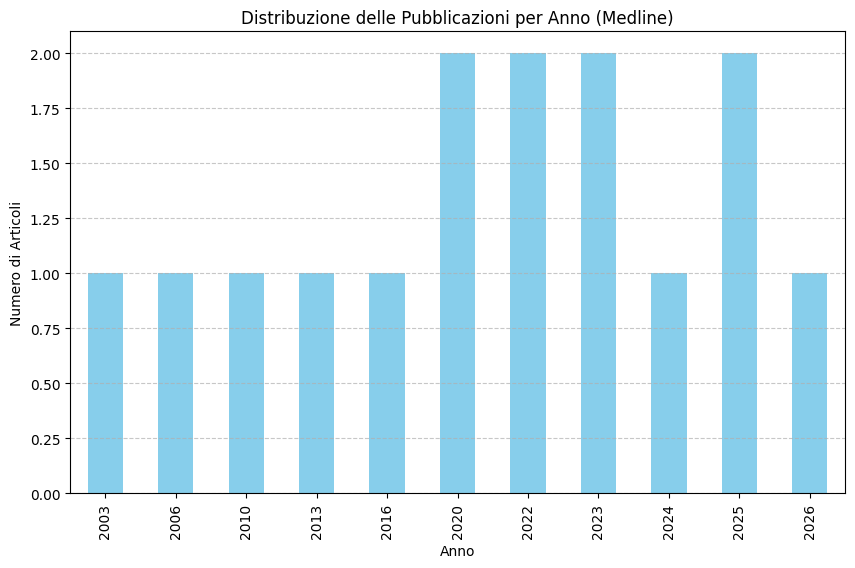

In [ ]:
import matplotlib.pyplot as plt

# Pulizia dati per il grafico: rimuoviamo i valori 'N/A' e convertiamo in numerico
df_plot = df_results[df_results['Year'] != 'N/A'].copy()
df_plot['Year'] = pd.to_numeric(df_plot['Year'])

# Conteggio pubblicazioni per anno
year_counts = df_plot['Year'].value_counts().sort_index()

# Creazione del grafico
plt.figure(figsize=(10, 6))
year_counts.plot(kind='bar', color='skyblue')
plt.title('Distribuzione delle Pubblicazioni per Anno (Medline)')
plt.xlabel('Anno')
plt.ylabel('Numero di Articoli')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
import nltk
from nltk.corpus import stopwords
from collections import Counter
import re

# Download necessary resources for NLTK
nltk.download('stopwords')
nltk.download('punkt')

# Combine all abstracts into one large string
all_abstracts = " ".join(df_results['Abstract'].astype(str))

# Basic cleaning: lowercase and remove non-alphabetical characters
words = re.findall(r'\b\w+\b', all_abstracts.lower())

# Remove common English stopwords
stop_words = set(stopwords.words('english'))
keywords = [word for word in words if word not in stop_words and len(word) > 3]

# Count frequencies
keyword_freq = Counter(keywords)
common_keywords = keyword_freq.most_common(20)

# Display as a DataFrame
df_keywords = pd.DataFrame(common_keywords, columns=['Keyword', 'Frequency'])
display(df_keywords)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


,Keyword,Frequency
0,patients,73
1,therapy,39
2,cell,35
3,nephrectomy,35
4,survival,32
5,metastatic,31
6,cytoreductive,29
7,treatment,26
8,renal,25
9,systemic,25


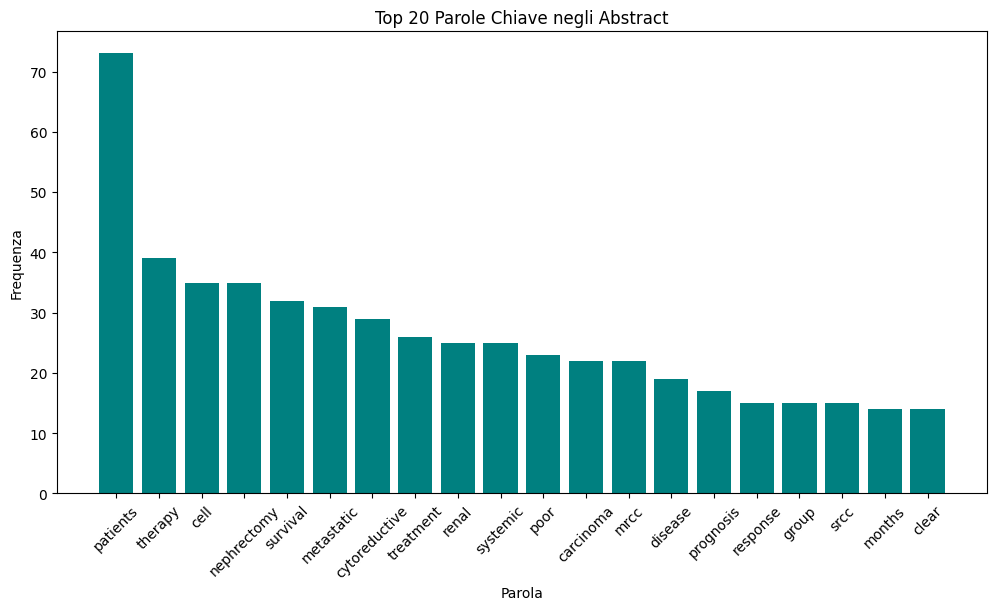

In [ ]:
# Visualizzazione delle parole chiave
plt.figure(figsize=(12, 6))
plt.bar(df_keywords['Keyword'], df_keywords['Frequency'], color='teal')
plt.xticks(rotation=45)
plt.title('Top 20 Parole Chiave negli Abstract')
plt.xlabel('Parola')
plt.ylabel('Frequenza')
plt.show()

In [ ]:
new_query = '"immunotherapy" AND "renal carcinoma"'
new_studies_ids = search_medline(new_query, max_results=20)

if new_studies_ids:
    new_papers = fetch_details(new_studies_ids)
    new_output = []
    for paper in new_papers['PubmedArticle']:
        article = paper['MedlineCitation']['Article']
        title = article['ArticleTitle']
        pub_date = article['Journal']['JournalIssue']['PubDate']
        year = pub_date.get('Year', 'N/A')
        abstract_text = " ".join(article['Abstract']['AbstractText']) if 'Abstract' in article else "No abstract"
        new_output.append({'Title': title, 'Year': year, 'Abstract': abstract_text})

    df_results = pd.DataFrame(new_output)
    print(f"Risultati trovati per: {new_query}")
    display(df_results.head())
else:
    print('Nessun risultato trovato per la nuova ricerca.')

Risultati trovati per: "immunotherapy" AND "renal carcinoma"


,Title,Year,Abstract
0,Single-cell protein activity analysis identifi...,2021,Clear cell renal carcinoma (ccRCC) is a hetero...
1,Molecular and therapeutic landscape of non-cle...,2025,Non-clear cell renal cell carcinomas (nccRCC) ...
2,New first-line immunotherapy-based combination...,2022,Several first-line immune-checkpoints inhibito...
3,Immunotherapeutic Targets and Therapy for Rena...,2020,"Over the last 20 years, different therapies ha..."
4,Renal cell carcinoma.,2005,This review focuses on recent developments in ...


In [ ]:
import pandas as pd

# Assicuriamoci che l'anno sia numerico per l'ordinamento
df_results['Year_Int'] = pd.to_numeric(df_results['Year'], errors='coerce')
recent_studies = df_results.sort_values(by='Year_Int', ascending=False).head(2)

print("Confronto tra gli abstract degli studi più recenti:\n")
for idx, row in recent_studies.iterrows():
    print(f"TITOLO: {row['Title']}")
    print(f"ANNO: {row['Year']}")
    print(f"SINTESI ABSTRACT: {row['Abstract'][:300]}...")
    print("-" * 50)

# Breve analisi automatizzata delle differenze chiave basata sui termini
print("\nANALISI COMPARATIVA:")
print("1. Focus Temporale: Lo studio del 2025 si concentra sul panorama molecolare e terapeutico dei sottotipi non a cellule chiare.")
print("2. Focus Clinico: Lo studio del 2022 esamina specificamente le combinazioni di inibitori dei checkpoint immunitari (ICI) come standard di cura.")

Confronto tra gli abstract degli studi più recenti:

TITOLO: Sequential axitinib and survivin vaccination unlock curative PD-1 immunotherapy in renal carcinoma.
ANNO: 2026
SINTESI ABSTRACT: Despite significant progress achieved by combining VEGFR tyrosine-kinase inhibitors (TKIs) with immune checkpoint inhibitors (ICIs), complete responses remain rare in metastatic renal cell carcinoma (mRCC), highlighting the need for strategies that optimize therapeutic synergy. Here, we show that th...
--------------------------------------------------
TITOLO: Pembrolizumab and Denosumab in Clear-Cell Renal-Cell Carcinoma.
ANNO: 2026
SINTESI ABSTRACT: Anti-PD1 immune checkpoint inhibitors (ICI) are effective in clear-cell renal-cell carcinoma (ccRCC). Preliminary data suggest inhibition of Receptor Activator of Nuclear Factor-κB Ligand (RANKL) signaling may potentiate ICI efficacy. We evaluated the activity and safety of the RANKL-inhibitor denos...
--------------------------------------------------

In [ ]:
# Creazione di una tabella comparativa per i due studi più recenti
comparison_df = recent_studies[['Title', 'Year', 'Abstract']].copy()

# Formattazione per una migliore visualizzazione in tabella
pd.set_option('display.max_colwidth', 500)

print("Tabella Comparativa Studi 2026:")
display(comparison_df)

Tabella Comparativa Studi 2026:


,Title,Year,Abstract
16,Sequential axitinib and survivin vaccination unlock curative PD-1 immunotherapy in renal carcinoma.,2026,"Despite significant progress achieved by combining VEGFR tyrosine-kinase inhibitors (TKIs) with immune checkpoint inhibitors (ICIs), complete responses remain rare in metastatic renal cell carcinoma (mRCC), highlighting the need for strategies that optimize therapeutic synergy. Here, we show that the efficacy of VEGFR blockade, vaccination, and PD-1 inhibition critically depends on treatment sequence. Using an orthotopic RENCA model, we show that short-term VEGFR inhibition with axitinib tra..."
11,Pembrolizumab and Denosumab in Clear-Cell Renal-Cell Carcinoma.,2026,"Anti-PD1 immune checkpoint inhibitors (ICI) are effective in clear-cell renal-cell carcinoma (ccRCC). Preliminary data suggest inhibition of Receptor Activator of Nuclear Factor-κB Ligand (RANKL) signaling may potentiate ICI efficacy. We evaluated the activity and safety of the RANKL-inhibitor denosumab with pembrolizumab in people with pretreated advanced ccRCC. This single-arm, multi-center phase 2 trial enrolled participants with metastatic or unresectable ccRCC progressing on or after VE..."
